# Week 09 (training): Conditioning the diffusion model

In Week 08 you built and trained the unconditional diffusion model — a
network that learns the *marginal* distribution of residuals across all
training cycles, samples from it, and is ablated to confirm the timestep
embedding earns its keep. This week adds the missing ingredient:
**conditioning** on each window's smoothed sunspot area `area_smoothed`
and universal-path latitude `mu_universal`. With those two scalars
threaded into the network, the model goes from "produces plausible
residuals on average" to "produces residuals targeted at the specific
window the caller is asking about."

The architectural change is small. The Dataset returns a dictionary with keys `{"r_clean", "cond"}`
where cond is the 2-vector `(area_smoothed, mu_universal)`. The MLP gets a
slightly wider input — `r_t` and the timestep embedding *and* the
conditioning vector all concatenated at layer zero. The LightningModule's
training step unpacks the tuple and passes `cond` through. The sampler
accepts a per-sample conditioning vector and threads it through every
reverse step. None of the diffusion-specific machinery from Week 08 —
the schedule, the forward equation, the ε-prediction objective, the
timestep embedding itself — changes.

**By the end of this notebook you should have:**
- A trained conditional diffusion model that learns p(r | area, mu) — saved
  as `ckpt_conditional.ckpt`.
- A sanity-checked architecture confirming that t-sensitivity *and*
  cond-sensitivity both work: holding r_t fixed and varying t changes the
  output, *and* holding r_t and t fixed and varying cond also changes the
  output. The conditioning ablation built into Week 08 (the
  `use_timestep_embedding=False` flag) has a direct conditioning analogue
  here: if your model is somehow ignoring `cond`, the cond-sensitivity
  check is the only thing that will catch it before the evaluation
  notebook's distributional comparisons silently lie.

In [ ]:
import os, subprocess, sys

# Keep this path if working in Colab
# repo_path = "/content/butterflai"

# Use this path if working locally
repo_path = "../../"

if not os.path.isdir(repo_path):
    subprocess.run(["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path], check=True)
else:
    try:
        subprocess.run(["git", "-C", repo_path, "pull"], check=True)
    except subprocess.CalledProcessError as e:
        print(f"git pull skipped: {e}")
sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()


In [3]:
%load_ext autoreload
%autoreload 2

import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
from einops import repeat

import pytorch_lightning as pl
from pytorch_lightning.loggers import WandbLogger, CSVLogger
import wandb


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
# ── locate Week 08/09 artifacts (split across two folders) ─────────────────
# The week-08 and week-09 deliverables are spread across weeks/week_08/
# and weeks/week_09/. We search both for each artifact independently so the
# notebook works regardless of where any given file sits.
def _find(filename, search_dirs):
    for d in search_dirs:
        p = os.path.join(d, filename)
        if os.path.isfile(p):
            return p
    return None

_cwd = os.getcwd()
_search_dirs = []
for _base in [_cwd] + [os.path.abspath(os.path.join(_cwd, *[".."] * i)) for i in range(0, 5)]:
    for _sub in [("weeks", "week_09"), ("weeks", "week_08")]:
        _candidate = os.path.join(_base, *_sub)
        if os.path.isdir(_candidate) and _candidate not in _search_dirs:
            _search_dirs.append(_candidate)
    if ("week_08" in _base or "week_09" in _base) and os.path.isdir(_base) and _base not in _search_dirs:
        _search_dirs.append(_base)

_unconditioned_py  = _find("unconditioned_infrastructure.py", _search_dirs)
_conditioned_py    = _find("conditioned_infrastructure.py",   _search_dirs)
_parquet_path      = _find("diffusion_windows.parquet", _search_dirs)
_classical_py      = _find("butterflAI_model.py",     _search_dirs)
_classical_weights = _find("official_model.npz",      _search_dirs)

_missing = [n for n, p in [
    ("unconditioned_infrastructure.py", _unconditioned_py),
    ("conditioned_infrastructure.py",   _conditioned_py),
    ("diffusion_windows.parquet", _parquet_path),
    ("butterflAI_model.py",     _classical_py),
    ("official_model.npz",      _classical_weights),
] if p is None]
if _missing:
    raise FileNotFoundError(
        f"Cannot locate {_missing} under weeks/week_08 or weeks/week_09. "
        f"Searched: {_search_dirs}"
    )

_repo_root = os.path.abspath(os.path.join(os.path.dirname(_conditioned_py), "..", ".."))
for _p in [_repo_root,
           os.path.dirname(_unconditioned_py),
           os.path.dirname(_conditioned_py),
           os.path.dirname(_classical_py)]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

# ── import: Week 08 reused machinery + Week 09 conditional templates ───────
from unconditioned_infrastructure import (
    make_cosine_schedule,
    sinusoidal_embedding, TimestepEmbedding,
    SampleQualityCallback,
)
from conditioned_infrastructure import (
    ConditionalResidualDataset,
    ConditionalDiffusionMLP,
    ConditionalDiffusionLightning,
    sample_conditional,
)

# ── load Week 07 outputs ───────────────────────────────────────────────────
windows_df = pd.read_parquet(_parquet_path)

LAT_BINS    = np.linspace(0, 45, 16)
BIN_WIDTH   = 3.0
BIN_CENTERS = 0.5 * (LAT_BINS[:-1] + LAT_BINS[1:])

# ── classical ButterflAI model (kept in scope for ad-hoc inspection) ───────
from butterflAI_model import ButterflAIModel
classical = ButterflAIModel(_classical_weights)

# ── cosine schedule (single source of truth from the Week 08 script) ───────
T = 200
alpha_np, sigma_np, _alpha_bar_np = make_cosine_schedule(T=T, s=0.008)

print(f"Loaded {len(windows_df)} windows from diffusion_windows.parquet")
print(f"  splits  : {windows_df['split'].value_counts().sort_index().to_dict()}")
print(f"  cycles  : {sorted(windows_df['cycle'].unique())}")
print(f"  cond raw ranges (train split):")
_train = windows_df[windows_df['split'] == 'train']
for col in ['area_smoothed', 'mu_universal']:
    print(f"    {col:14s}: mean={_train[col].mean():.3f}, std={_train[col].std():.3f}, "
          f"min={_train[col].min():.3f}, max={_train[col].max():.3f}")
print(f"  schedule: T={T}, arrays length {len(alpha_np)}")
print(classical)

Loaded 373 windows from diffusion_windows.parquet
  splits  : {'test': 86, 'train': 232, 'val': 55}
  cycles  : [np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
  cond raw ranges (train split):
    area_smoothed : mean=86.796, std=43.082, min=12.346, max=225.569
    mu_universal  : mean=14.644, std=4.014, min=8.045, max=25.863
  schedule: T=200, arrays length 201
<ButterflAIModel  N_hemicycles=26  NLL=3.0708  coverage=0.963>


---
## Task 45 — `ConditionalResidualDataset` (template in `conditioned_infrastructure.py`)

The new Dataset returns a **dict** instead of a tuple:

```
{"r_clean": float32 tensor (15,),
 "cond":    float32 tensor (2,)}
```

Dict-returning Datasets are the convention worth adopting from Week 09
onward. Dicts are self-documenting at access time (`batch["cond"]` needs
no memory of position), extensible (adding a `cycle_phase` field later
does not break unpacking sites in the training step, the sampler, or the
evaluation notebook — only the consumers that actually use the new field
need updating), and PyTorch's default DataLoader collation handles
dict-of-tensors natively. The tuple-returning version of this dataset
would work too, but every new conditioning variable would require
chasing down every `r, cond = batch` line in the codebase. The dict
pattern scales; the tuple pattern does not.

Two pieces of standardization are still happening, exactly as discussed
in the script's docstring:

**Residuals** are standardized per-bin to unit variance, exactly as in
Week 08. Each split computes its own `bin_means` / `bin_stds`. The
LightningModule persists the train-split bin statistics as buffers so the
sampler can de-standardize at inference time.

**Conditioning** is standardized using *train-split-only* statistics —
this is the part that requires care. The network learns to expect cond
inputs in the train-set's normalized scale. If the validation dataset
standardized using its own statistics, the network would see
distributionally different conditioning at evaluation time than it saw at
training time, which silently corrupts every cond-sensitivity check
downstream.

The template handles this for you: when you construct any
`ConditionalResidualDataset` without passing `cond_means` / `cond_stds`,
the constructor computes them from the *train rows of the supplied
DataFrame* regardless of which split the Dataset itself represents. So
the `val` dataset gets the train-set normalization automatically.

**Open `conditioned_infrastructure.py` and implement:**
- `ConditionalResidualDataset.__init__` (residual standardization +
  conditioning standardization with the train-split-only constraint).
- `ConditionalResidualDataset.__len__`.
- `ConditionalResidualDataset.__getitem__` (returns the dict described
  above with the right keys, dtypes, and shapes).


---
## Task 46 — Visualize the conditional dataset

A dataset class is one of the easier objects to silently misimplement.
For the conditional version there is *one more thing* to check beyond
the Week 08 sanity tests: that conditioning standardization actually uses
train-split statistics for the validation set. If your val dataset has
cond mean far from zero or cond std far from one — but the *train*
dataset does have cond mean zero and cond std one — you accidentally
standardized each split with its own stats, which is the failure mode
this Dataset spec was designed to prevent.

**Tasks:**
- Instantiate `train_dataset` and `val_dataset`. Print their lengths.
  The counts should match the splits printed by the setup cell.
- Pull `train_dataset[0]` and verify it is a **dict** with the right keys
  (`"r_clean"`, `"cond"`), each value a float32 tensor of the expected
  shape, finite. If you accidentally returned a tuple from `__getitem__`,
  this is where you find out.
- Print the `cond_means` and `cond_stds` of both datasets. They must be
  **identical** across train and val. If they differ, the
  train-split-only rule was violated.
- For the train dataset, verify that the cond mean is ≈ 0 and the cond
  std is ≈ 1 (both within ~1e-5). For val, cond mean and std will be
  near these but not exactly — you are applying train statistics to a
  different distribution, so deviations from 0/1 are expected and
  meaningful.
- Plot the raw `(area_smoothed, mu_universal)` joint distribution coloured
  by split, then the normalized joint distribution. The normalized
  version should be centred on (0, 0) with the train cloud reaching
  roughly ±2 in each coordinate.


train_dataset: 232 samples
val_dataset:   55 samples
train_dataset[0]: correct dict structure, dtypes, shapes, and finite values.
cond_means (train==val): [86.796486 14.644381]
cond_stds  (train==val): [42.989254   4.0053964]

Train cond mean: [5.2410982e-08 2.2094826e-08]  (should be ~0)
Train cond std:  [1.0000001 1.0000001]   (should be ~1)
Train cond standardization check passed.

Val cond mean:   [0.43228516 0.1299719 ]  (deviation from 0 expected)
Val cond std:    [1.2963812 0.9543127]   (deviation from 1 expected)


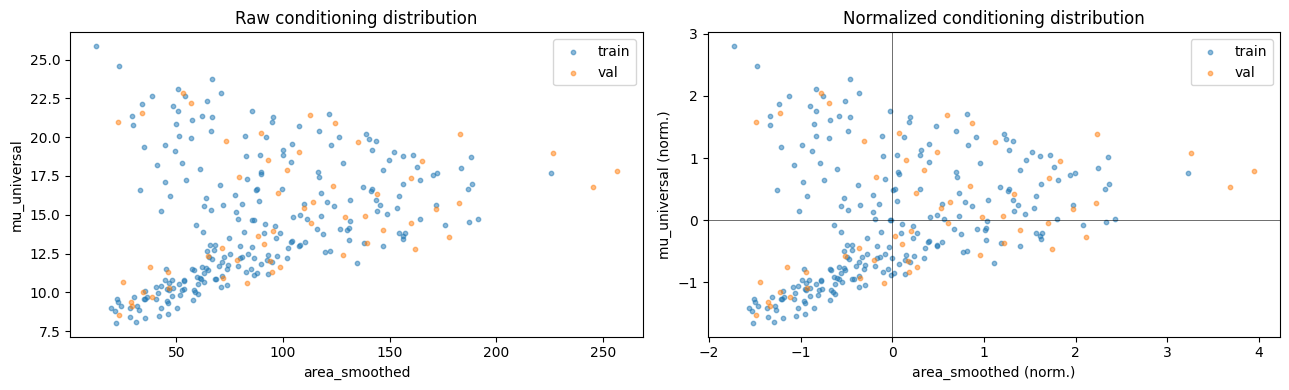


Task 46 complete.


In [5]:
# Task 46 -- instantiate, sanity-check, visualize the conditional datasets

# 1. Instantiate both datasets
train_dataset = ConditionalResidualDataset(windows_df, "train")
val_dataset   = ConditionalResidualDataset(windows_df, "val")

print(f"train_dataset: {len(train_dataset)} samples")
print(f"val_dataset:   {len(val_dataset)} samples")

# 2. Verify dict structure, dtypes, shapes, finiteness
item0 = train_dataset[0]
assert isinstance(item0, dict), f"Expected dict, got {type(item0).__name__}"
assert set(item0.keys()) == {"r_clean", "cond"}, f"Wrong keys: {set(item0.keys())}"
assert item0["r_clean"].shape == (15,), f"Wrong r_clean shape: {item0['r_clean'].shape}"
assert item0["cond"].shape == (2,),    f"Wrong cond shape: {item0['cond'].shape}"
assert item0["r_clean"].dtype == torch.float32
assert item0["cond"].dtype    == torch.float32
assert torch.isfinite(item0["r_clean"]).all()
assert torch.isfinite(item0["cond"]).all()
print("train_dataset[0]: correct dict structure, dtypes, shapes, and finite values.")

# 3. cond_means/cond_stds must be identical between train and val
assert torch.allclose(train_dataset.cond_means, val_dataset.cond_means), \
    "cond_means differ -- train-split-only rule violated"
assert torch.allclose(train_dataset.cond_stds, val_dataset.cond_stds), \
    "cond_stds differ -- train-split-only rule violated"
print(f"cond_means (train==val): {train_dataset.cond_means.numpy()}")
print(f"cond_stds  (train==val): {train_dataset.cond_stds.numpy()}")

# 4. Train cond should be approx N(0,1)
all_cond_train = torch.stack([train_dataset[i]["cond"] for i in range(len(train_dataset))]).numpy()
cond_mean_train = all_cond_train.mean(axis=0)
cond_std_train  = all_cond_train.std(axis=0)
print(f"\nTrain cond mean: {cond_mean_train}  (should be ~0)")
print(f"Train cond std:  {cond_std_train}   (should be ~1)")
assert abs(all_cond_train.mean(axis=0)).max() < 1e-4
assert abs(all_cond_train.std(axis=0) - 1.0).max() < 1e-4
print("Train cond standardization check passed.")

all_cond_val = torch.stack([val_dataset[i]["cond"] for i in range(len(val_dataset))]).numpy()
cond_mean_val = all_cond_val.mean(axis=0)
cond_std_val  = all_cond_val.std(axis=0)
print(f"\nVal cond mean:   {cond_mean_val}  (deviation from 0 expected)")
print(f"Val cond std:    {cond_std_val}   (deviation from 1 expected)")

# 5. Plots: raw and normalized conditioning distributions coloured by split
_train_rows = windows_df[windows_df["split"] == "train"]
_val_rows   = windows_df[windows_df["split"] == "val"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(_train_rows["area_smoothed"], _train_rows["mu_universal"],
                alpha=0.5, s=10, color="C0", label="train")
axes[0].scatter(_val_rows["area_smoothed"],   _val_rows["mu_universal"],
                alpha=0.5, s=10, color="C1", label="val")
axes[0].set_xlabel("area_smoothed"); axes[0].set_ylabel("mu_universal")
axes[0].set_title("Raw conditioning distribution"); axes[0].legend()

axes[1].scatter(all_cond_train[:, 0], all_cond_train[:, 1],
                alpha=0.5, s=10, color="C0", label="train")
axes[1].scatter(all_cond_val[:, 0],   all_cond_val[:, 1],
                alpha=0.5, s=10, color="C1", label="val")
axes[1].axhline(0, color="k", linewidth=0.4)
axes[1].axvline(0, color="k", linewidth=0.4)
axes[1].set_xlabel("area_smoothed (norm.)"); axes[1].set_ylabel("mu_universal (norm.)")
axes[1].set_title("Normalized conditioning distribution"); axes[1].legend()

plt.tight_layout(); plt.show()
print("\nTask 46 complete.")

---
## Task 47 — Build the DataLoaders

Same DataLoader pattern as Week 08. PyTorch's default collation handles
the Dataset's dict return automatically: each key in the per-item dict
becomes a key in the per-batch dict, with the leading batch dimension
prepended to every tensor value. So `next(iter(train_loader))` is a
dict:

```
{"r_clean": (B, 15) float32, "cond": (B, 2) float32}
```

Verify this explicitly — the LightningModule's `_shared_step` will read
from these keys, and a tuple-returning Dataset (from accidentally writing
`return r, cond` instead of `return {"r_clean": r, "cond": cond}` in
`__getitem__`) will give batches that look superficially similar but
fail in the training step several layers deeper.


In [6]:
# Task 47 -- DataLoaders + batch sanity check

BATCH_SIZE = 64

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = torch.utils.data.DataLoader(
    val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

for name, loader in [("train", train_loader), ("val", val_loader)]:
    batch = next(iter(loader))
    assert isinstance(batch, dict), f"expected dict, got {type(batch).__name__}"
    assert set(batch.keys()) == {"r_clean", "cond"}, f"wrong keys: {set(batch.keys())}"
    assert batch["r_clean"].shape[1] == 15 and batch["cond"].shape[1] == 2
    assert batch["r_clean"].dtype == torch.float32
    assert batch["cond"].dtype    == torch.float32
    print(f"{name:5s}: {len(loader):3d} batches/epoch, "
          f"r_clean shape={tuple(batch['r_clean'].shape)}, "
          f"cond shape={tuple(batch['cond'].shape)}")

print("\nTask 47 complete.")

train:   4 batches/epoch, r_clean shape=(64, 15), cond shape=(64, 2)
val  :   1 batches/epoch, r_clean shape=(55, 15), cond shape=(55, 2)

Task 47 complete.


---
## Task 48 — `ConditionalDiffusionMLP` (template in `conditioned_infrastructure.py`)

The forward signature changes from `(r_t, t) → eps_hat` to
`(r_t, t, cond) → eps_hat`. The conditioning vector is concatenated
alongside r_t and the timestep embedding at the input layer:

```
x = torch.cat([r_t, t_emb, cond], dim=-1)   # shape (B, 15 + 128 + 2)
```

No new architectural concepts beyond that. The `TimestepEmbedding` is
reused unchanged from Week 08, imported from `unconditioned_infrastructure.py`.

**Open `conditioned_infrastructure.py` and implement** the `__init__` and
`forward` of `ConditionalDiffusionMLP`. Default constructor arguments
are pinned to match what the rest of this notebook expects.

---
## Task 49 — Sanity tests: t-sensitivity *and* cond-sensitivity

Week 08 introduced the t-sensitivity check: hold r_t fixed, vary t,
verify the output measurably changes. That check defends against a
silently-broken timestep embedding.

The conditional model needs the analogous check for the conditioning:
**cond-sensitivity** — hold r_t and t fixed, vary `cond` across the
range of (area, mu) values the model will actually see, verify the output
measurably changes. If it does not, your model is silently unconditional
no matter what the class name says, and every distributional comparison
in the evaluation notebook will give answers that look reasonable but
are not measuring what you think they are.

Run **both** checks on a freshly-initialized model before training. The
checks are inexpensive; the failure mode they catch is exactly the kind
of silent corruption that wastes days of training time.

For the cond-sensitivity check, use a *realistic* range of conditioning
values — sample five (area, mu) points spanning roughly ±2 standard
deviations of the train distribution (the normalized range the model
will actually encounter), not arbitrary synthetic values. This makes the
check both more meaningful and a closer analogue of the t-sensitivity
check, which uses real timestep values.

t-sensitivity: max pairwise L2 = 0.0103  (must be > 0)
cond-sensitivity: max pairwise L2 = 0.0221  (must be > 0)


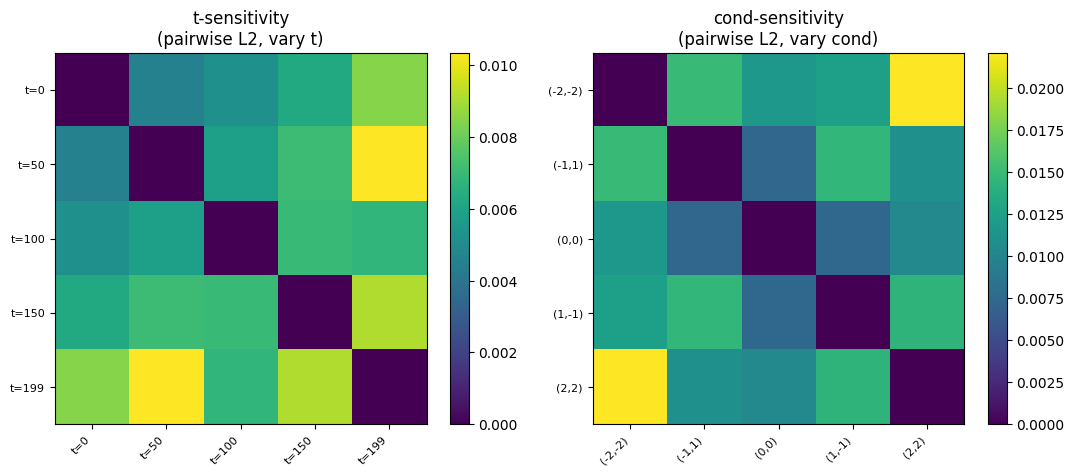


Task 49: both t-sensitivity and cond-sensitivity checks passed.


In [7]:
# Task 49 -- t-sensitivity + cond-sensitivity on a freshly-initialized model

torch.manual_seed(1)
model_test = ConditionalDiffusionMLP()

r_t_fixed = torch.randn(15)
t_values  = torch.tensor([0, T//4, T//2, 3*T//4, T-1], dtype=torch.long)
cond_zero = torch.zeros(2)

# 1. t-sensitivity: hold r_t and cond fixed, vary t
r_t_batch  = repeat(r_t_fixed, "d -> n d", n=5)
cond_batch = repeat(cond_zero,  "d -> n d", n=5)
with torch.no_grad():
    out_t = model_test(r_t_batch, t_values, cond_batch)

t_pairwise = (out_t[None] - out_t[:, None]).norm(dim=-1)
print(f"t-sensitivity: max pairwise L2 = {t_pairwise.max().item():.4f}  (must be > 0)")
assert t_pairwise[~torch.eye(5, dtype=torch.bool)].min() > 1e-6, \
    "t-sensitivity FAILED: outputs identical across t"

# 2. cond-sensitivity: hold r_t and t fixed, vary cond across realistic +-2 std range
cond_values = torch.tensor([[-2., -2.], [-1., 1.], [0., 0.], [1., -1.], [2., 2.]])
t_fixed   = torch.full((5,), T // 2, dtype=torch.long)
r_t_batch = repeat(r_t_fixed, "d -> n d", n=5)
with torch.no_grad():
    out_c = model_test(r_t_batch, t_fixed, cond_values)

c_pairwise = (out_c[None] - out_c[:, None]).norm(dim=-1)
print(f"cond-sensitivity: max pairwise L2 = {c_pairwise.max().item():.4f}  (must be > 0)")
assert c_pairwise[~torch.eye(5, dtype=torch.bool)].min() > 1e-6, \
    "cond-sensitivity FAILED: outputs identical across cond"

# Side-by-side pairwise-distance heatmaps
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
t_labels    = ["t=0", f"t={T//4}", f"t={T//2}", f"t={3*T//4}", f"t={T-1}"]
cond_labels = ["(-2,-2)", "(-1,1)", "(0,0)", "(1,-1)", "(2,2)"]
for ax, mat, title, labels in [
    (axes[0], t_pairwise.numpy(),    "t-sensitivity\n(pairwise L2, vary t)",    t_labels),
    (axes[1], c_pairwise.numpy(), "cond-sensitivity\n(pairwise L2, vary cond)", cond_labels),
]:
    im = ax.imshow(mat, cmap="viridis")
    ax.set_xticks(range(5)); ax.set_yticks(range(5))
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_title(title)
    fig.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

print("\nTask 49: both t-sensitivity and cond-sensitivity checks passed.")

---
## Task 50 — `ConditionalDiffusionLightning` (template in `conditioned_infrastructure.py`)

The only structural changes from Week 08's `DiffusionLightning`:

1. `_shared_step` reads `batch["r_clean"]` and `batch["cond"]` from the
   dict batch (rather than unpacking a tuple) and passes `cond` through
   to `self.model(r_t, t, cond)`.
2. The constructor accepts `cond_means` and `cond_stds` and registers them
   as buffers alongside the existing `bin_means` / `bin_stds`. This keeps
   *all* relevant standardization statistics on the checkpoint, so the
   evaluation notebook can load and re-normalize conditioning without
   needing the training-time dataset.
3. `save_hyperparameters(ignore=[...])` now ignores the four statistics
   tensors alongside `model`, `alpha`, `sigma`.

The `configure_optimizers` method is *identical* to Week 08's. Copy it
from `unconditioned_infrastructure.py`.

**Open `conditioned_infrastructure.py` and implement** `__init__`,
`_shared_step`, and `configure_optimizers`. The `training_step` and
`validation_step` are filled in for you — they call `_shared_step` and
log loss exactly as in Week 08.

---
## Task 51 — Train the conditional model


In [8]:
# Task 51 -- Train the conditional diffusion model

import numpy as _np_seed; _np_seed.random.seed(42)
torch.manual_seed(42)

# De-standardize residuals to physical units for reference
bin_means_np = train_dataset.bin_means.numpy()
bin_stds_np  = train_dataset.bin_stds.numpy()
all_train      = torch.stack([train_dataset[i]["r_clean"] for i in range(len(train_dataset))]).numpy()
all_val        = torch.stack([val_dataset[i]["r_clean"]   for i in range(len(val_dataset))]).numpy()
all_train_phys = all_train * bin_stds_np + bin_means_np
all_val_phys   = all_val   * bin_stds_np + bin_means_np

MAX_EPOCHS = 10000

model_cond = ConditionalDiffusionMLP()
lightning_cond = ConditionalDiffusionLightning(
    model=model_cond, alpha=alpha_np, sigma=sigma_np, T=T, lr=1e-3,
    scheduler="cosine", weight_decay=1e-4,
    bin_means=train_dataset.bin_means, bin_stds=train_dataset.bin_stds,
    cond_means=train_dataset.cond_means, cond_stds=train_dataset.cond_stds,
)

try:
    logger_cond = WandbLogger(
        project="butterflai-wk09",
        name=f"conditional_b{BATCH_SIZE}_e{MAX_EPOCHS}_cos",
        save_dir="./wandb_logs",
    )
except Exception as _e:
    print(f"WandB unavailable ({_e}); using CSVLogger.")
    logger_cond = CSVLogger("./csv_logs", name="conditional")

# SampleQualityCallback calls the unconditional sample() which is not available
# on the conditional module, so we omit it and rely on loss curves + 09d for
# distributional checks.
trainer_cond = pl.Trainer(
    max_epochs=MAX_EPOCHS, logger=logger_cond,
    accelerator="auto", devices="auto",
    log_every_n_steps=10, enable_progress_bar=True,
)

trainer_cond.fit(lightning_cond, train_loader, val_loader)
trainer_cond.save_checkpoint("./ckpt_conditional.ckpt")
try:
    import wandb
    wandb.finish()
except Exception:
    pass

print("\nTraining complete. Checkpoint saved to ./ckpt_conditional.ckpt")

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
wandb: WARNING `resume` will be ignored since W&B syncing is set to `offline`. Starting a new run with ru

Loading `train_dataloader` to estimate number of stepping batches.
c:\Users\larsg\anaconda3_new\envs\fresh_env\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
c:\Users\larsg\anaconda3_new\envs\fresh_env\lib\site-packages\pytorch_lightning\loops\fit_loop.py:321: The number of training batches (4) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.

  | Name  | Type                    | Params | Mode  | FLOPs
------------------------------------------------------------------
0 | model | ConditionalDiffusionMLP | 78.5 K | train | 0    
------------------------------------------------------------------
78.5 K    Trainable params
0         Non-trainable params


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\larsg\anaconda3_new\envs\fresh_env\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10000` reached.
`weights_only` was not set, defaulting to `False`.


epoch,▁▁▁▁▂▂▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▆▆▆▆▆▆▆▇▇▇█
train_loss,█▄▆▃▃▄▅▄▄▄▃▃▄▃▂▂▂▂▃▂▂▂▁▂▁▂▂▂▂▁▂▁▂▂▁▁▂▂▁▂
trainer/global_step,▁▁▂▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇██
val_loss,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▅▅▆▅▃▄▆▆▅▄▄▄▇▆▃▄▄▃▅▅▅▅▄▃█▃
epoch,9999
train_loss,0.1922
trainer/global_step,39999
val_loss,0.85183



Training complete. Checkpoint saved to ./ckpt_conditional.ckpt


---
## Handoff to `09d_conditioned_evaluate.ipynb`

You should now have one checkpoint file in this directory:
- `ckpt_conditional.ckpt` (conditional diffusion model)

Together with the Week 08 unconditional checkpoint `ckpt_full.ckpt`, this
gives the evaluation notebook two trained models to compare. The
evaluation notebook will:

- Reload both checkpoints and re-verify their t-sensitivity (and, for the
  conditional model, cond-sensitivity) on the *loaded* state — defends
  against silent state-dict corruption during loading.
- Sample residuals from the conditional model targeted at specific
  validation-window conditioning, visualize them.
- Compare the conditional samples' distribution to held-out validation
  residuals, against the unconditional baseline.

The headline value-add metric — `compute_global_nll` on held-out cycles,
classical alone vs. classical + conditional residuals — is its own
notebook (`09e_diffusion_NLL_evaluation.ipynb`). That's the question
the program has been pointing at since Week 03, and it gets its own
clean space to be answered.

**If you change anything in `conditioned_infrastructure.py` after this notebook
has been run**, the autoreload magic in the evaluation notebook will pick
it up — but checkpoints saved with the old code will not be compatible
with new class signatures. If you change a class signature, retrain.
